這份資料集用來預測信用卡申請是否會被核准。資料共有 16 個欄位，其中前 15 欄為申請者背景、財務與信用相關特徵，最後 1 欄為 Approval_Status，作為預測目標
+ Feature: Gender, Age, Debt, Married, Bank_Customer, Education_Level, Ethnicity, Years_Employed, Prior_Default, Employed, Credit_Score, Drivers_License, Citizen, Zip_Code, Income
+ Target: Approval_Status

In [1]:
# 匯入套件並載入資料集
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,f1_score,roc_curve,roc_auc_score,confusion_matrix

cc_apps = pd.read_csv("cc_approvals.data", header=None)

觀察資料後發現，缺失值以 ? 表示，因此先將其轉換為空值，再依欄位型態進行填補：數值欄位以平均值補值，類別欄位以眾數補值

In [2]:
# 將 "?" 轉換為缺失值
cc_apps = cc_apps.replace("?", np.nan)

# 依欄位型態填補缺失值
for col in cc_apps.columns:
    if cc_apps[col].dtype in [np.float64, np.int64]:
        cc_apps[col] = cc_apps[col].fillna(cc_apps[col].mean())
    else:
        cc_apps[col] = cc_apps[col].fillna(cc_apps[col].mode()[0])

將原始資料集拆分為特徵資料 X 與目標資料 y，再進一步切分為 80% 訓練集與 20% 測試集，用於後續模型訓練與評估

In [3]:
# 分離特徵和目標資料，並生成訓練集和測試集
X = cc_apps.iloc[:, :-1]
y = cc_apps.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

針對類別型特徵進行 One-hot encoding，並透過 align 對齊訓練集與測試集的欄位，確保兩者具有相同的特徵維度。最後將欄位名稱轉為字串型態，以符合後續模型輸入需求

In [4]:
# 找出類別型欄位
categorical_columns = X.select_dtypes(include=['object', 'category']).columns

# 對訓練集與測試集進行 One-hot encoding
X_train_encoded = pd.get_dummies(X_train, columns=categorical_columns, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_columns, drop_first=True)

# 對齊欄位，避免訓練集與測試集欄位不一致
X_train_encoded, X_test_encoded = X_train_encoded.align(
    X_test_encoded, join='left', axis=1, fill_value=0
)

# 將欄位名稱轉成字串型態
X_train_encoded.columns = X_train_encoded.columns.astype(str)
X_test_encoded.columns = X_test_encoded.columns.astype(str)

使用 StandardScaler 對特徵進行標準化，降低不同尺度特徵對模型訓練的影響，特別是對距離或邊界敏感的模型更為重要

In [5]:
# 對訓練集與測試集進行標準化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

建立多種分類模型作為基準比較，並先以預設參數進行初步訓練，並以Accuracy、F1 Score、ROC-AUC等指標進行評估

In [6]:
# 建立多種分類模型並進行初步比較
models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True)
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:,1]
    acc = accuracy_score(y_test,y_pred)
    f1 = f1_score(y_test,y_pred,pos_label='+' if '+' in y.unique() else 1)
    auc = roc_auc_score(y_test,y_prob)
    
    results[name] = {
        "Accuracy":acc,
        "F1 Score":f1,
        "ROC-AUC":auc
    }

result_df = pd.DataFrame.from_dict(results,orient="index")
result_df = result_df.reset_index().rename(columns={"index":"model"})

print(result_df)

                 model  Accuracy  F1 Score   ROC-AUC
0  Logistic Regression  0.782609  0.776119  0.847059
1        Random Forest  0.847826  0.842105  0.898634
2                  KNN  0.644928  0.625954  0.685504
3                  SVM  0.695652  0.655738  0.803571


為不同模型設定超參數搜尋範圍，讓後續 GridSearch 能在合理範圍內尋找最佳組合

In [7]:
# 定義各模型的超參數搜尋範圍
param_grids = {
    "Logistic Regression": {
        "C": [0.01, 0.1, 1, 10],
        "solver": ["liblinear", "lbfgs"],
        "max_iter": [100, 200, 500]
    },
    "Random Forest": {
        "n_estimators": [50, 100, 200],
        "max_depth": [None, 10, 20],
        "max_features": ["sqrt", "log2"]
    },
    "KNN": {
        "n_neighbors": [3, 5, 7, 11],
        "weights": ["uniform", "distance"],
        "metric": ["euclidean", "manhattan"]
    },
    "SVM": {
        "C": [0.1, 1, 10],
        "kernel": ["linear", "rbf", "poly"],
        "gamma": ["scale", "auto"]
    }
}

本專案以 Accuracy 作為主要評估指標，並使用 10-fold cross validation 取得 Best CV Score，同時以獨立測試集計算 Test Accuracy，以比較模型的泛化表現

In [8]:
# 進行 GridSearch 並記錄各模型最佳結果

final_results = []

for name, model in models.items():
    print(f"Running GridSearch for {name}...")
    grid = GridSearchCV(
        estimator=model, 
        param_grid=param_grids[name], 
        cv=10, 
        scoring={
            "accuracy": "accuracy",
            "f1": "f1",
            "roc_auc": "roc_auc"
        },
        refit="accuracy")
    grid_result = grid.fit(X_train_scaled, y_train)    
    best_model = grid_result.best_estimator_
    test_accuracy = accuracy_score(y_test, best_model.predict(X_test_scaled))
    
    final_results.append({
        "Model": name,
        "Best Params": grid_result.best_params_,
        "Best CV Score": grid_result.best_score_,
        "Test Accuracy": test_accuracy
    })

# 整理成表格，方便比較
final_results_df = pd.DataFrame(final_results)
print('\n')
print(final_results_df)

Running GridSearch for Logistic Regression...
Running GridSearch for Random Forest...
Running GridSearch for KNN...
Running GridSearch for SVM...


                 Model  ... Test Accuracy
0  Logistic Regression  ...      0.804348
1        Random Forest  ...      0.840580
2                  KNN  ...      0.724638
3                  SVM  ...      0.797101

[4 rows x 4 columns]


繪製最佳模型 Random Forest 的 Confusion Matrix

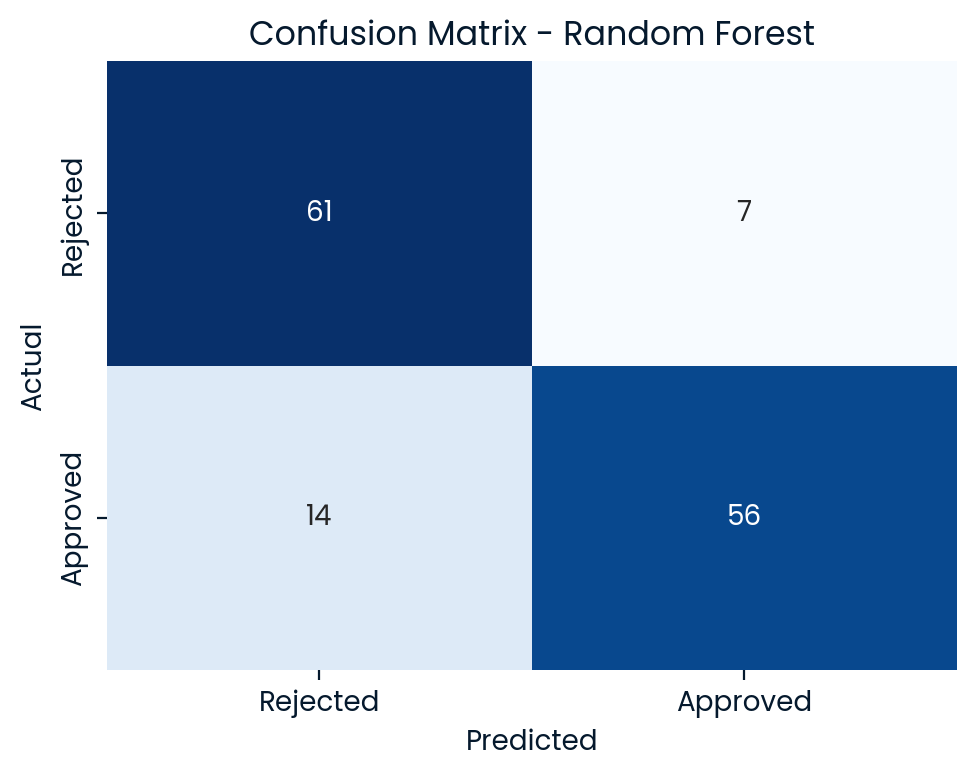

In [9]:
y_test_num = y_test.map({'+':1, '-':0})

rf_model = models["Random Forest"]
y_pred = rf_model.predict(X_test_scaled)

y_pred_num = pd.Series(y_pred).map({'+':1, '-':0})

cm = confusion_matrix(y_test_num, y_pred_num)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Rejected","Approved"],
            yticklabels=["Rejected","Approved"])
plt.title("Confusion Matrix - Random Forest")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

透過 ROC Curve 與 ROC-AUC 比較各模型在不同閾值下的分類能力；AUC 越高代表模型區分正負類的能力越好

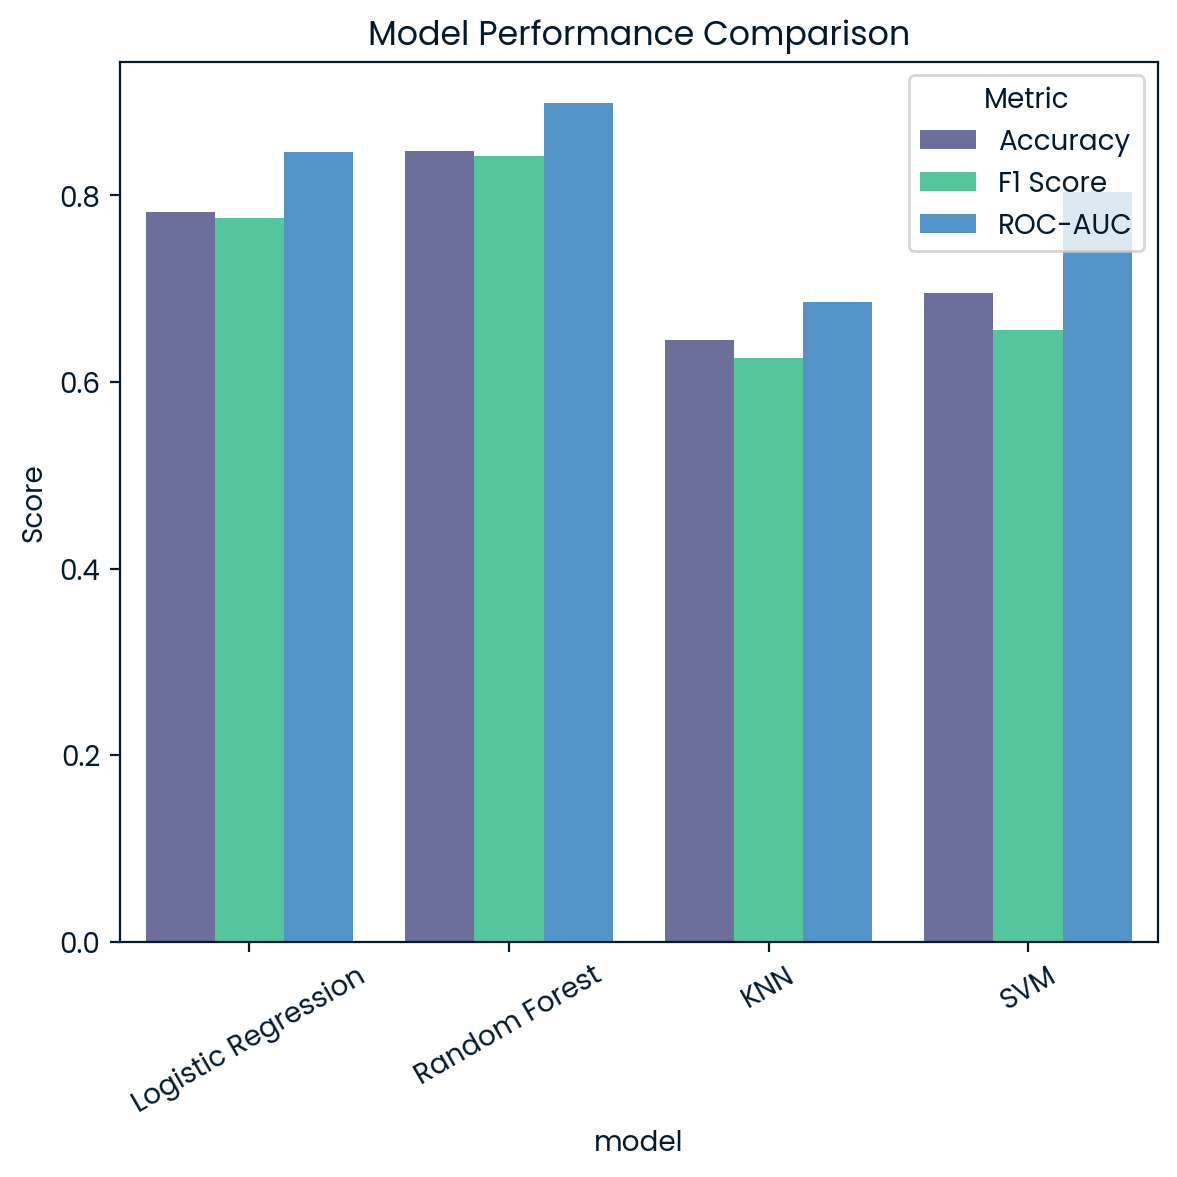

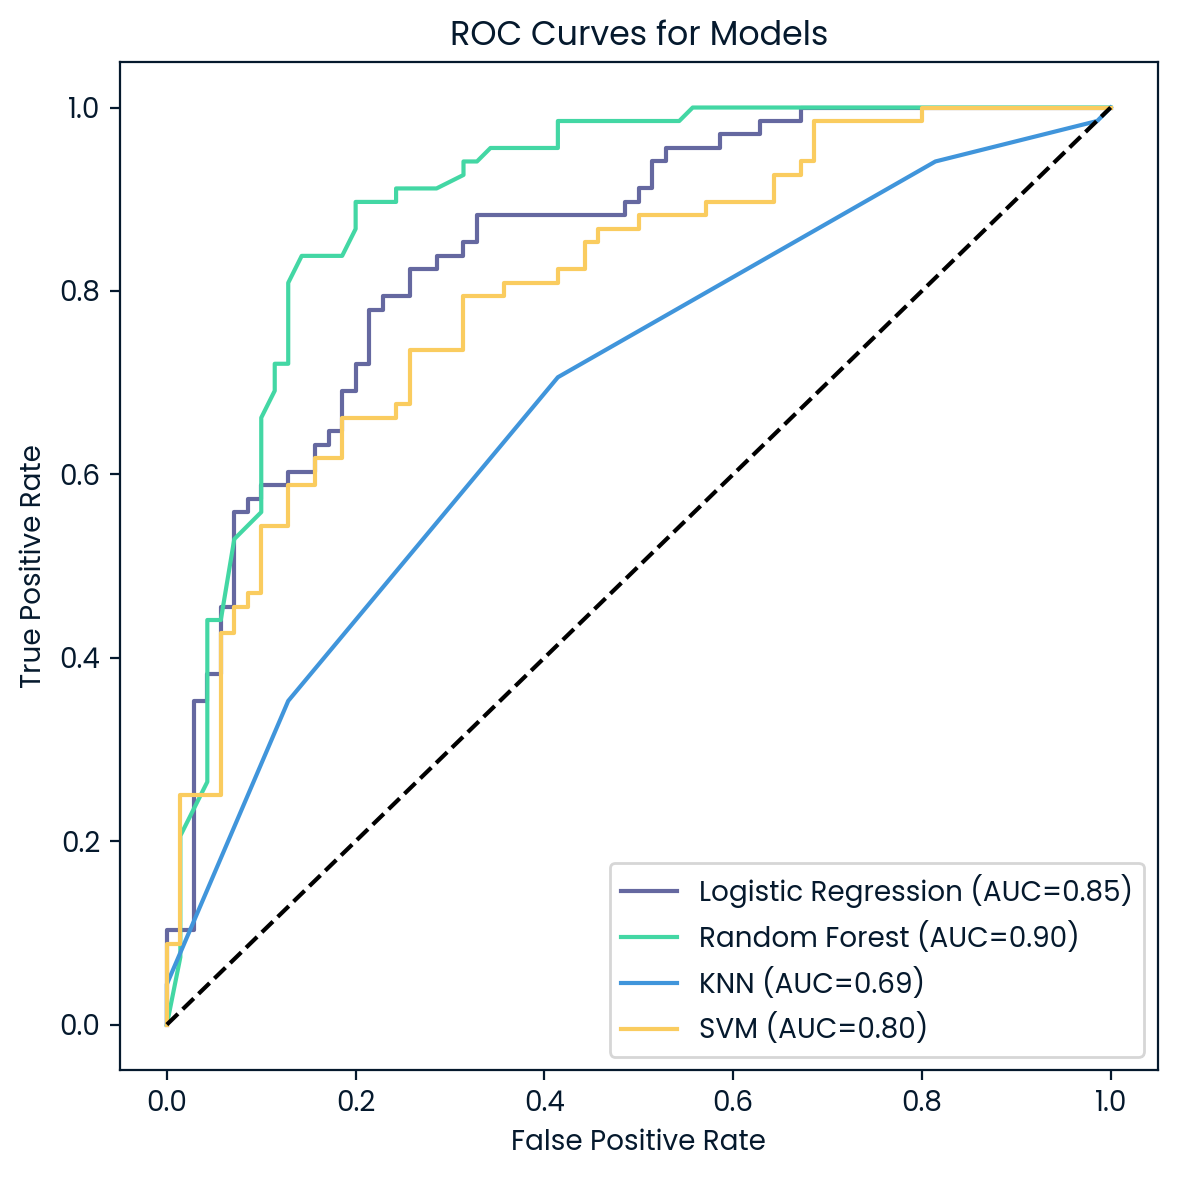

In [10]:
# 模型表現比較圖 (Accuracy / F1 / ROC-AUC)
plt.figure(figsize=(6,6))
sns.barplot(
    data=result_df.melt(id_vars="model", var_name="Metric", value_name="Score"),
    x="model", y="Score", hue="Metric"
)
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=30)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

# ROC曲線圖
y_test_num = y_test.map({'+':0, '-':1})

plt.figure(figsize=(6, 6))

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_score = model.decision_function(X_test_scaled)

    fpr, tpr, _ = roc_curve(y_test_num, y_score)
    auc = roc_auc_score(y_test_num, y_score)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.2f})")

plt.plot([0, 1], [0, 1], "k--")
plt.title("ROC Curves for Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

## 專案結論
綜合測試集表現與 ROC-AUC，本專案選擇 **Random Forest** 作為最佳模型，因為它在 Accuracy、F1 Score 與 ROC-AUC 上都表現最佳。  

因此後續的混淆矩陣與結果分析也以 Random Forest 為主，作為最終模型展示。相較於單看 Accuracy，F1 Score 與 ROC-AUC 更能反映模型在分類任務中的整體品質，因此本專案同時納入這些指標進行比較。